# Customer Segmentation & Behavior Analysis

**Overview**: This notebook focuses on data preparation, feature engineering, and exploratory data analysis (EDA). The primary objective is to segment customers based on their purchasing behavior, lifetime value, and engagement metrics to drive targeted marketing strategies

## 1. Setup & Data Loading
In this section, we initialize our analytical environment, import required libraries, and ingest the pre-cleaned datasets for downstream processing.

### 1.1. Import Libraries & Environment Setup

In [116]:
# Import core analytical and visualization libraries
import pandas as pd
import numpy as np
import os
import calendar
import warnings

# Data visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

# Ignore warning messages for cleaner notebook output
warnings.filterwarnings('ignore')

# Set plotting style and default figure size for consistency
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1.2. Load Datasets
Loading the cleaned `.parquet` files from the processed dataset directory.

In [117]:
DATA_PATH = '../dataset/02_after_clean/'
print("Loading data...")

df_customers = pd.read_parquet(DATA_PATH + 'customers.parquet')
df_promotions = pd.read_parquet(DATA_PATH + 'promotions.parquet')
df_geography = pd.read_parquet(DATA_PATH + 'geography.parquet')

df_orders = pd.read_parquet(DATA_PATH + 'orders.parquet')
df_returns = pd.read_parquet(DATA_PATH + 'returns.parquet')

print("Load data successfully")

Loading data...
Load data successfully


## 2. Data Preprocessing & Feature Engineering
To accurately segment our customers, we need to extract meaningful features from raw transaction logs.

### 2.1. Time-Based Features Generation
Calculating temporal metrics such as the average days between purchases (interval), customer tenure, and recency to understand engagement frequency.

In [118]:
# Sort orders chronologically per customer
df_orders = df_orders.sort_values(by=['customer_id', 'order_date'])

# Calculate the interval (in days) between consecutive orders for each customer
df_orders['interval_prev_order'] = (
    df_orders.groupby('customer_id')['order_date']
    .diff()
    .dt.days
)

# Calculate the average interval between orders for each customer
inter_order_gap = (
    df_orders.groupby('customer_id')['interval_prev_order']
    .apply(lambda x: x.iloc[1:].mean())
)
df_customers['avg_interval'] = df_customers['customer_id'].map(inter_order_gap).fillna(0.0)

# Determine the first and last order dates
first_order = df_orders.groupby('customer_id')['order_date'].first()
last_order = df_orders.groupby('customer_id')['order_date'].last()

# Map dates to customers (fallback to signup_date if no orders)
df_customers['first_order_date'] = df_customers['customer_id'].map(first_order).fillna(df_customers['signup_date'])
df_customers['last_order_date'] = df_customers['customer_id'].map(last_order).fillna(df_customers['signup_date'])

# Calculate Recency and Tenure (Reference date: Dec 31, 2022)
current_date = pd.to_datetime('2022-12-31', dayfirst=True)
df_customers['recency_days'] = (current_date - df_customers['last_order_date']).dt.days
df_customers['tenure_days'] = (current_date - df_customers['first_order_date']).dt.days

display(df_customers.sample(3))

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel,avg_interval,first_order_date,last_order_date,recency_days,tenure_days
116921,151039,97632,Bien Hoa,2022-10-19,Male,45-54,referral,1383.000000,2016-07-03,2020-04-16,989,2372
26523,34220,47040,Phu Ly,2021-10-02,Male,45-54,organic_search,334.285714,2013-07-16,2019-12-12,1115,3455
13646,17639,33028,Viet Tri,2020-03-30,Female,25-34,paid_search,168.761905,2013-03-16,2022-11-28,33,3577


### 2.2. Order & Payment Features Aggregation
Extracting order-level financial metrics and aggregating them at the customer level to determine total lifetime orders, actual revenue, and refund/cancellation rates.

#### Order-level feature preparation

In [119]:
# Calculate total refund amount per order
total_refund_per_order = df_returns.groupby('order_id')['refund_amount'].sum()
df_orders['refund_amount'] = df_orders['order_id'].map(total_refund_per_order).fillna(0.0)

# Identify monetary values of cancelled and returned orders
df_orders['cancel_refund'] = (df_orders[df_orders['order_status'] == 'cancelled']['payment_value'])
df_orders['cancel_refund'] = df_orders['cancel_refund'].fillna(0.0)
df_orders['total_refund'] = df_orders['cancel_refund'] + df_orders['refund_amount']

# Calculate actual payment and boolean flag for successful orders
df_orders['actual_payment'] = df_orders['payment_value'] - df_orders['total_refund']
df_orders['is_actual_order'] = (df_orders['order_status'] != 'cancelled') & (df_orders['order_status'] != 'returned')

display(df_orders.sample(3))


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,payment_value,installments,interval_prev_order,refund_amount,cancel_refund,total_refund,actual_payment,is_actual_order
230793,297650,2015-06-24,133020,93933,returned,paypal,mobile,direct,28187.40,3 periods,137.0,6369.95,0.0,6369.95,21817.45,False
142158,183522,2014-05-26,67323,23322,delivered,paypal,mobile,email_campaign,11048.25,12 periods,156.0,0.00,0.0,0.00,11048.25,True
586992,756937,2021-04-23,119086,60610,delivered,cod,mobile,organic_search,20932.40,1 period,1032.0,0.00,0.0,0.00,20932.40,True


#### Customer-level aggregation

In [120]:
# Count orders by status
total_order_per_cus = df_orders.groupby('customer_id')['order_id'].count()
total_return_order_per_cus = df_orders[df_orders['order_status'] == 'returned'].groupby('customer_id')['order_id'].count()
total_cancelled_order_per_cus = df_orders[df_orders['order_status'] == 'cancelled'].groupby('customer_id')['order_id'].count()

# Sum payments by status
total_paid_per_cus = df_orders.groupby('customer_id')['payment_value'].sum()
total_refund_per_cus = df_orders.groupby('customer_id')['refund_amount'].sum()
total_refund_cancelled_per_cus = df_orders.groupby('customer_id')['cancel_refund'].sum()
actual_paid_per_cus = df_orders.groupby('customer_id')['actual_payment'].sum()

# Map aggregated data to the customers dataframe
df_customers['total_order'] = df_customers['customer_id'].map(total_order_per_cus).fillna(0)
df_customers['return_order'] = df_customers['customer_id'].map(total_return_order_per_cus).fillna(0)
df_customers['cancel_order'] = df_customers['customer_id'].map(total_cancelled_order_per_cus).fillna(0)
df_customers['actual_order'] = df_customers['total_order'] - df_customers['return_order'] - df_customers['cancel_order']

df_customers['total_paid'] = df_customers['customer_id'].map(total_paid_per_cus).fillna(0)
df_customers['total_refund'] = df_customers['customer_id'].map(total_refund_per_cus).fillna(0)
df_customers['total_refund_cancel'] = df_customers['customer_id'].map(total_refund_cancelled_per_cus).fillna(0)
df_customers['actual_paid'] = df_customers['customer_id'].map(actual_paid_per_cus).fillna(0)

# Calculate Return/Cancellation Rate
df_customers['return_cancel_rate'] = ((df_customers['return_order'] + df_customers['cancel_order']) / df_customers['total_order']).fillna(-1.0)

display(df_customers.sample(3))

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel,avg_interval,first_order_date,last_order_date,...,tenure_days,total_order,return_order,cancel_order,actual_order,total_paid,total_refund,total_refund_cancel,actual_paid,return_cancel_rate
68761,88834,56464,Hoi An,2022-01-16,Male,35-44,email_campaign,0.0,2022-01-16,2022-01-16,...,349,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,-1.0
2589,3348,15923,Lao Cai,2019-04-09,Female,35-44,direct,0.0,2020-03-24,2020-03-24,...,1012,1.0,0.0,0.0,1.0,2467.87,0.0,0.0,2467.87,0.0
85736,110738,65264,Hoi An,2022-11-21,Female,35-44,social_media,0.0,2022-11-21,2022-11-21,...,40,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,-1.0


### 2.3. Rule-Based Customer Segmentation
Categorizing customers into 7 distinct, mutually exclusive segments (including the default 'loyal' segment) based on their historical purchasing behavior, recency, and lifetime value.

In [121]:
# Define thresholds for segmentation
six_months_ago = pd.to_datetime('2022-05-31', dayfirst=True)
three_years_ago = pd.to_datetime('2019-12-31', dayfirst=True)

# Use quantiles for dynamic thresholds
high_inter_threshold = df_customers['avg_interval'].quantile(0.25)
high_paid_threshold = df_customers['actual_paid'].quantile(0.75)

# Define segmentation conditions
conditions = [
    # Non buyer
    df_customers['total_order'] == 0,
    # New customer
    ((df_customers['signup_date'] >= six_months_ago) |
     (df_customers['first_order_date'] >= six_months_ago)) & 
    (df_customers['total_order'] <= 2),
    # Low quality customer
    (df_customers['return_cancel_rate'] >= 0.75) | 
    (df_customers['actual_paid'] < df_customers['total_paid'] * 0.5),
    # Old customer
    (df_customers['last_order_date'] < three_years_ago),
    # High-value loyal
    (df_customers['actual_order'] > 1) & 
    (df_customers['return_cancel_rate'] < 0.3) & 
    (df_customers['actual_paid'] >= high_paid_threshold) &
    (df_customers['recency_days'] <= df_customers['avg_interval']),
    # At-risk
    #(df_customers['actual_order'] == 1) |
    (df_customers['return_cancel_rate'] >= 0.5) | 
    (df_customers['recency_days'] > df_customers['avg_interval'] * 1.5),
]

# Map conditions to segment labels
choices = [
    'non_buyer',
    'new_customer',
    'low_quality',
    'old_customer',
    'high_value_loyal',
    'at_risk'
]

# Apply segmentation, default to 'loyal' if no conditions are met
df_customers['customer_segment'] = np.select(conditions, choices, default='loyal')
df_customers['customer_segment'] = df_customers['customer_segment'].astype('category')

In [122]:
print(df_customers['customer_segment'].value_counts())

customer_segment
old_customer        35816
non_buyer           31684
loyal               16790
at_risk             15588
high_value_loyal    11660
low_quality          6176
new_customer         4216
Name: count, dtype: int64


### 2.4. Data Merging & Formatting
Merging geographical data and segment tags back to operational tables (returns, orders) for deeper cohort analysis and tracking daily aggregated metrics.

In [123]:
# Prepare Return Data by attaching Customer Segment
df_returns = df_returns.merge(df_orders[['order_id', 'customer_id']], on='order_id', how='left')
df_returns = df_returns.merge(df_customers[['customer_id', 'customer_segment']], on='customer_id', how='left')

# Add Geography to Customers
df_customers = df_customers.merge(df_geography[['zip', 'region']], on='zip', how='left')

# Prepare Time-Series Order & Payment Data grouped by Segment
df_orders = df_orders.merge(df_customers[['customer_id', 'customer_segment']], on='customer_id', how='left')

daily_segment_df = df_orders.groupby(['order_date', 'customer_segment'], observed=True).agg(
    total_order=('order_id', 'count'),
    actual_order=('is_actual_order', 'sum'),
    return_cancel_order=('is_actual_order', lambda x: (x == 0).sum()),
    total_paid=('payment_value', 'sum'), 
    actual_paid=('actual_payment', 'sum'),
    total_refund=('total_refund', 'sum')
).reset_index()

display(daily_segment_df.sample(3))


,order_date,customer_segment,total_order,actual_order,return_cancel_order,total_paid,actual_paid,total_refund
4253,2014-07-21,at_risk,61,52,9,1436522.75,1244252.27,192270.48
14076,2019-04-22,at_risk,55,48,7,2016506.76,1819707.78,196798.98
10252,2017-06-08,new_customer,1,0,1,101100.40,57824.18,43276.22


### 2.5. Promotional Data Preparation
Formatting datetime features and extracting seasonal indicators to analyze the life cycle and distribution of promotional campaigns.

In [124]:
# Convert date columns to datetime objects and calculate promotion duration
df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])
df_promotions['duration_days'] = (df_promotions['end_date'] - df_promotions['start_date']).dt.days

# Verify the timeline boundaries of the promotions dataset
newest_end_promo = df_promotions[df_promotions['end_date'] == df_promotions['end_date'].max()]
print(f"Latest promotion end date: {newest_end_promo['end_date'].iloc[0]}")

oldest_start_promo = df_promotions[df_promotions['start_date'] == df_promotions['start_date'].min()]
print(f"\nEarliest promotion start date: {oldest_start_promo['start_date'].iloc[0]}")

# Extract time components for seasonality analysis
df_promotions['month'] = df_promotions['start_date'].dt.month
df_promotions['year'] = df_promotions['start_date'].dt.year

# Create Day-Month strings to identify recurring annual events
df_promotions['start_day_month'] = df_promotions['start_date'].dt.strftime('%d-%m')
df_promotions['end_day_month'] = df_promotions['end_date'].dt.strftime('%d-%m')

# Sort promotions chronologically by their annual start day
df_promotions = df_promotions.sort_values(by=['start_day_month', 'start_date'])

Latest promotion end date: 2022-12-31 00:00:00

Earliest promotion start date: 2013-01-31 00:00:00


### 2.6. Feature Selection & Data Export
Dropping irrelevant columns to optimize memory usage, reviewing the final structure of our dataset and exporting the prepared data for the EDA phase.

In [125]:
EXPORT_PATH = '../dataset/03_after_eda/'
os.makedirs(EXPORT_PATH, exist_ok=True)

# Drop operational columns that are no longer needed for high-level segment analysis
df_returns = df_returns.drop(columns=['order_id', 'product_id', 'return_date', 'return_quantity'])
df_customers = df_customers.drop(columns=['zip', 'city', 'gender', 'age_group', 'acquisition_channel'])

# Review dataset schemas and non-null counts
df_orders.info()
df_returns.info()
df_customers.info()
daily_segment_df.info()
df_promotions.info()

# Export the processed dataframes
df_customers.to_parquet(EXPORT_PATH + 'customers_segment.parquet', index=False)
df_promotions.to_parquet(EXPORT_PATH + 'promotions.parquet', index=False)
daily_segment_df.to_parquet(EXPORT_PATH + 'daily_segment.parquet', index=False)

print("Data preparation complete.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             646945 non-null  string        
 1   order_date           646945 non-null  datetime64[ns]
 2   customer_id          646945 non-null  string        
 3   zip                  646945 non-null  string        
 4   order_status         646945 non-null  category      
 5   payment_method       646945 non-null  category      
 6   device_type          646945 non-null  category      
 7   order_source         646945 non-null  category      
 8   payment_value        646945 non-null  float64       
 9   installments         646945 non-null  category      
 10  interval_prev_order  556699 non-null  float64       
 11  refund_amount        646945 non-null  float64       
 12  cancel_refund        646945 non-null  float64       
 13  total_refund  

## 3. Exploratory Data Analysis (EDA)
This section visually explores the distinct behavioral patterns, financial contributions, and temporal trends of our defined customer segments to derive actionable marketing insights.


### 3.1. Defining Color Palette for Segments
Maintaining consistent colors for segments across all plots helps the audience easily identify trends.

In [126]:
# Define segment names and map them to a Seaborn palette
segment_names = [
    'at_risk', 'loyal', 'old_customer', 
    'high_value_loyal', 'non_buyer', 'low_quality', 'new_customer'
]

tab10_colors = sns.color_palette("tab10", len(segment_names))
segment_palette = dict(zip(segment_names, tab10_colors))

### 3.2. Customer Segmentation Overview Dashboard
A comprehensive 3x2 visualization grid comparing key behavioral metrics, revenue contributions, and signup trends across the newly created customer segments.

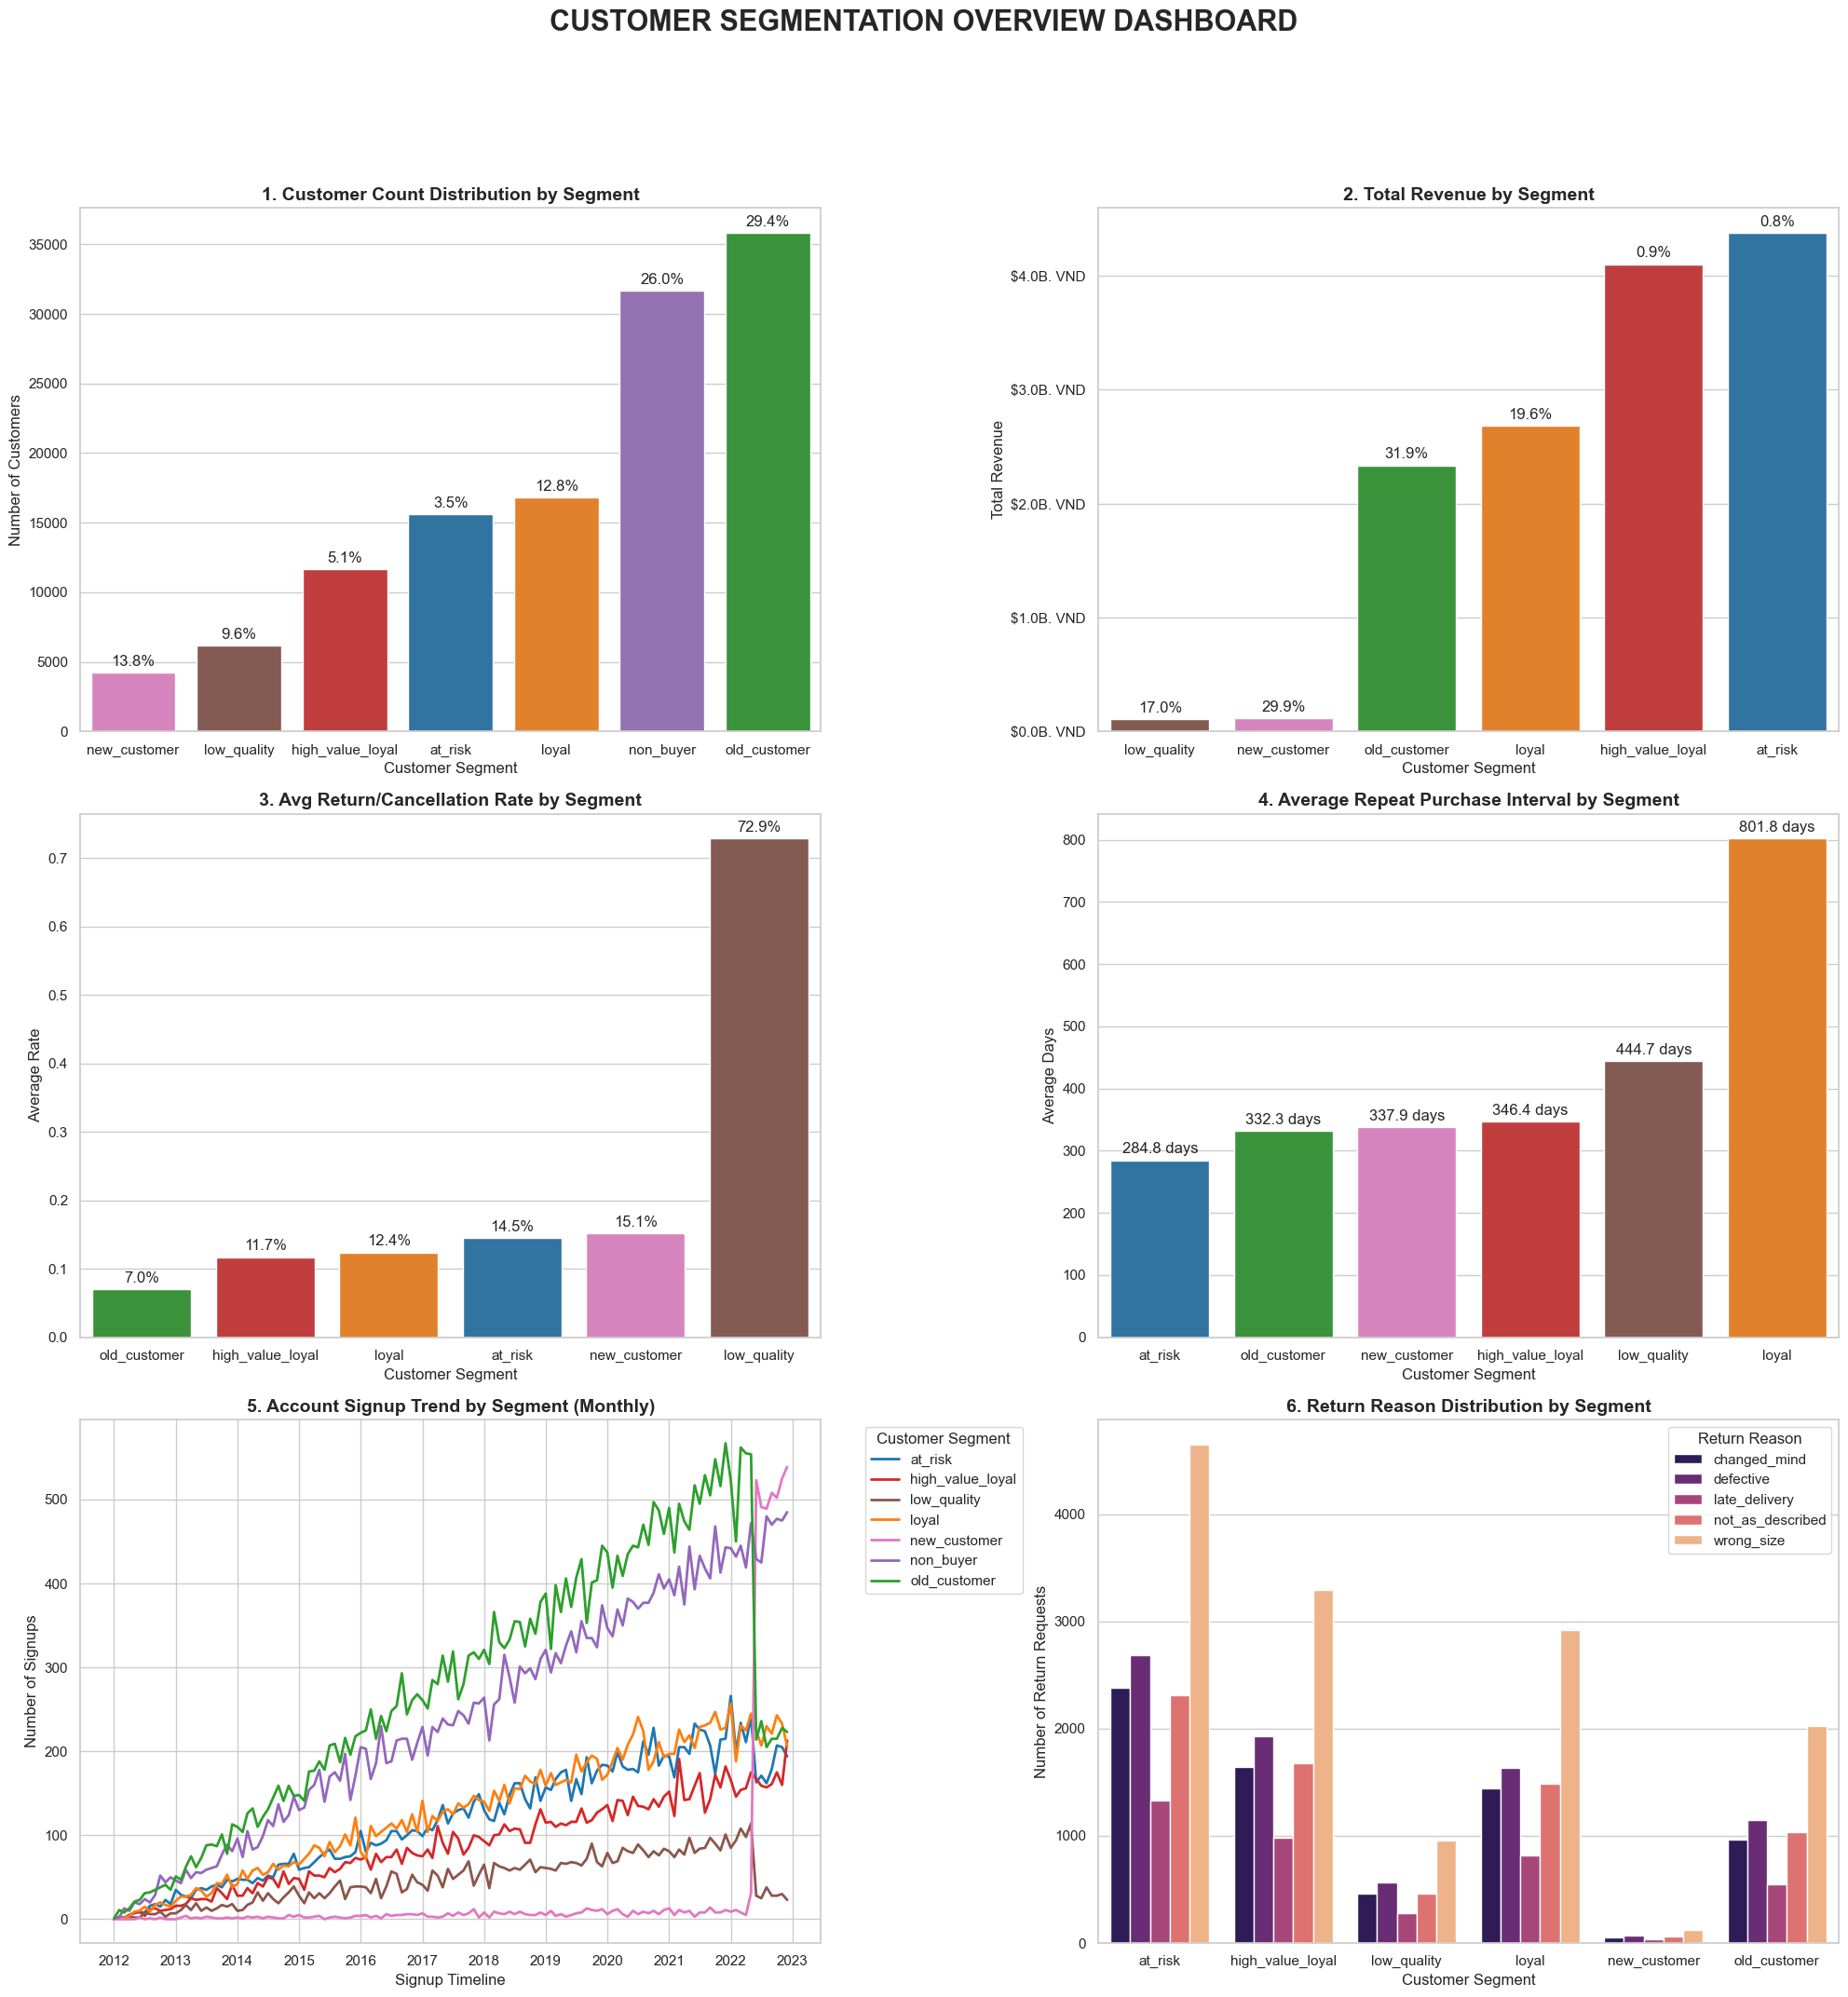

In [127]:
# Exclude 'non_buyer' for specific behavioral analyses
df_buyers = df_customers[df_customers['customer_segment'] != 'non_buyer'].copy()
df_buyers['customer_segment'] = df_buyers['customer_segment'].cat.remove_unused_categories()


# Initialize a 3x2 subplot grid
fig, axes = plt.subplots(3, 2, figsize=(20, 21))
fig.suptitle('CUSTOMER SEGMENTATION OVERVIEW DASHBOARD', fontsize=22, fontweight='bold', y=1.02)


# ==========================================
# Plot 1: Customer Count Distribution [0, 0]
# ==========================================
counts = df_customers['customer_segment'].value_counts().reset_index()
counts.columns = ['customer_segment', 'count']
total_customers = counts['count'].sum()
counts['percentage'] = (counts['count'] / total_customers) * 100
counts = counts.sort_values(by='count', ascending=True).reset_index(drop=True)

sns.barplot(
    data=counts, 
    x='customer_segment', 
    y='count',
    hue='customer_segment', 
    palette=segment_palette,
    order=counts['customer_segment'], 
    dodge=False, legend=False,
    ax=axes[0, 0]
)
axes[0, 0].set_title('1. Customer Count Distribution by Segment', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Number of Customers', fontsize=12)
axes[0, 0].set_xlabel('Customer Segment', fontsize=12)
# axes[0, 0].tick_params(axis='x', rotation=45)

for p, pct in zip(axes[0, 0].patches, counts['percentage']):
    axes[0, 0].annotate(f'{pct:.1f}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')


# ==========================================
# Plot 2: Total Revenue by Segment [0, 1]
# ==========================================
revenue_by_segment = df_buyers.groupby('customer_segment')['actual_paid'].sum().reset_index()
total_revenue = revenue_by_segment['actual_paid'].sum()
revenue_by_segment['revenue_pct'] = (revenue_by_segment['actual_paid'] / total_revenue) * 100
revenue_by_segment = revenue_by_segment.sort_values(by='actual_paid').reset_index(drop=True)

sns.barplot(
    data=revenue_by_segment, 
    x='customer_segment', 
    y='actual_paid',
    hue='customer_segment', 
    palette=segment_palette,
    order=revenue_by_segment['customer_segment'], 
    dodge=False, legend=False,
    ax=axes[0, 1]
)
axes[0, 1].set_title('2. Total Revenue by Segment', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Total Revenue', fontsize=12)
axes[0, 1].set_xlabel('Customer Segment', fontsize=12)
# axes[0, 1].tick_params(axis='x', rotation=45)

def currency_formatter(x, pos):
    return f'${x / 1e9:.1f}B. VND' 
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(currency_formatter))

for p, pct in zip(axes[0, 1].patches, revenue_by_segment['revenue_pct']):
    axes[0, 1].annotate(f'{pct:.1f}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')


# ==========================================
# Plot 3: Avg Return/Cancel Rate [1, 0]
# ==========================================
behavior_df = df_buyers.groupby('customer_segment')['return_cancel_rate'].mean().reset_index()
behavior_df = behavior_df.sort_values(by='return_cancel_rate', ascending=True).reset_index(drop=True)

sns.barplot(
    data=behavior_df, 
    x='customer_segment', 
    y='return_cancel_rate',
    hue='customer_segment', 
    palette=segment_palette,
    order=behavior_df['customer_segment'], 
    dodge=False, legend=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title('3. Avg Return/Cancellation Rate by Segment', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Average Rate', fontsize=12)
axes[1, 0].set_xlabel('Customer Segment', fontsize=12)
# axes[1, 0].tick_params(axis='x', rotation=45)

for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height() * 100:.1f}%",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')


# ==========================================
# Plot 4: Avg Repeat Purchase Interval [1, 1]
# ==========================================
interval_by_segment = df_buyers.groupby('customer_segment')['avg_interval'].mean().reset_index()
interval_by_segment = interval_by_segment.sort_values(by='avg_interval', ascending=True).reset_index(drop=True)

sns.barplot(
    data=interval_by_segment, 
    x='customer_segment', 
    y='avg_interval',
    hue='customer_segment', 
    palette=segment_palette,
    order=interval_by_segment['customer_segment'], 
    dodge=False, legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('4. Average Repeat Purchase Interval by Segment', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Average Days', fontsize=12)
axes[1, 1].set_xlabel('Customer Segment', fontsize=12)
# axes[1, 1].tick_params(axis='x', rotation=45)

for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.1f} days",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')


# ==========================================
# Plot 5: Account Signup Trends (Monthly) [2, 0]
# ==========================================
df_customers['signup_month'] = df_customers['signup_date'].dt.to_period('M').dt.to_timestamp()
monthly_segment_counts = df_customers.groupby(['signup_month', 'customer_segment']).size().reset_index(name='count')

sns.lineplot(
    data=monthly_segment_counts, 
    x='signup_month', 
    y='count',
    hue='customer_segment', 
    linewidth=2.0,
    palette=segment_palette, 
    ax=axes[2, 0]
)
axes[2, 0].set_title('5. Account Signup Trend by Segment (Monthly)', fontsize=14, fontweight='bold')
axes[2, 0].set_ylabel('Number of Signups', fontsize=12)
axes[2, 0].set_xlabel('Signup Timeline', fontsize=12)

axes[2, 0].xaxis.set_major_locator(mdates.YearLocator())
axes[2, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2, 0].legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')


# ==========================================
# Plot 6: Return Reason Distribution [2, 1]
# ==========================================
df_returns_clean = df_returns[df_returns['customer_segment'] != 'non_buyer'].copy()
df_returns_clean['customer_segment'] = df_returns_clean['customer_segment'].cat.remove_unused_categories()

sns.countplot(
    data=df_returns_clean, 
    x='customer_segment', 
    hue='return_reason',
    palette='magma', 
    ax=axes[2, 1]
)
axes[2, 1].set_title('6. Return Reason Distribution by Segment', fontsize=14, fontweight='bold')
axes[2, 1].set_ylabel('Number of Return Requests', fontsize=12)
axes[2, 1].set_xlabel('Customer Segment', fontsize=12)
# axes[2, 1].tick_params(axis='x', rotation=45)
axes[2, 1].legend(title='Return Reason')

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### INSIGHTS & BUSINESS IMPLICATIONS
- **Visual Context**: This dashboard transitions our view from "mass statistics" to "segmented behaviors," revealing exactly who brings in the cash and who generates operational costs.
- **Key Findings**:
    - **The Pareto Reality**: The `high_value_loyal` and `loyal` segments make up a modest portion of the customer base (roughly 18% combined) but completely dominate total revenue (generating over **50%**).
    - **Cost Drainers**: The `low_quality` segment exhibits an alarmingly high return/cancellation rate (**72.9%**). They generate transactions but ultimately yield minimal net value.
    - **Churn Accumulation**: The largest segment by volume is `old_customer` (**29.4%**). While historical acquisition was successful, the business is clearly struggling with retention.
- **Actionable Recommendations**:
    - **Protect the Core**: Allocate a dedicated *VIP customer* care budget (e.g., proactive support, early access to sales) for the `high_value_loyal` group to protect the main cash flow.
    - **Restrict High-Risk Segments**: Implement automated systemic limits for the `low_quality` segment (e.g., disabling COD options or removing free shipping) to cut reverse logistics costs.
    - **Win-back Campaigns**: Trigger personalized email marketing for `old_customer`. Reactivating past buyers is generally cheaper than acquiring new ones.

### 3.3. Bi-weekly Transaction & Revenue Trends
Analyzing long-term transaction and revenue patterns across different customer segments. We apply a bi-weekly resampling interval to smooth out daily volatility while preserving macro trends over a 10-year period.

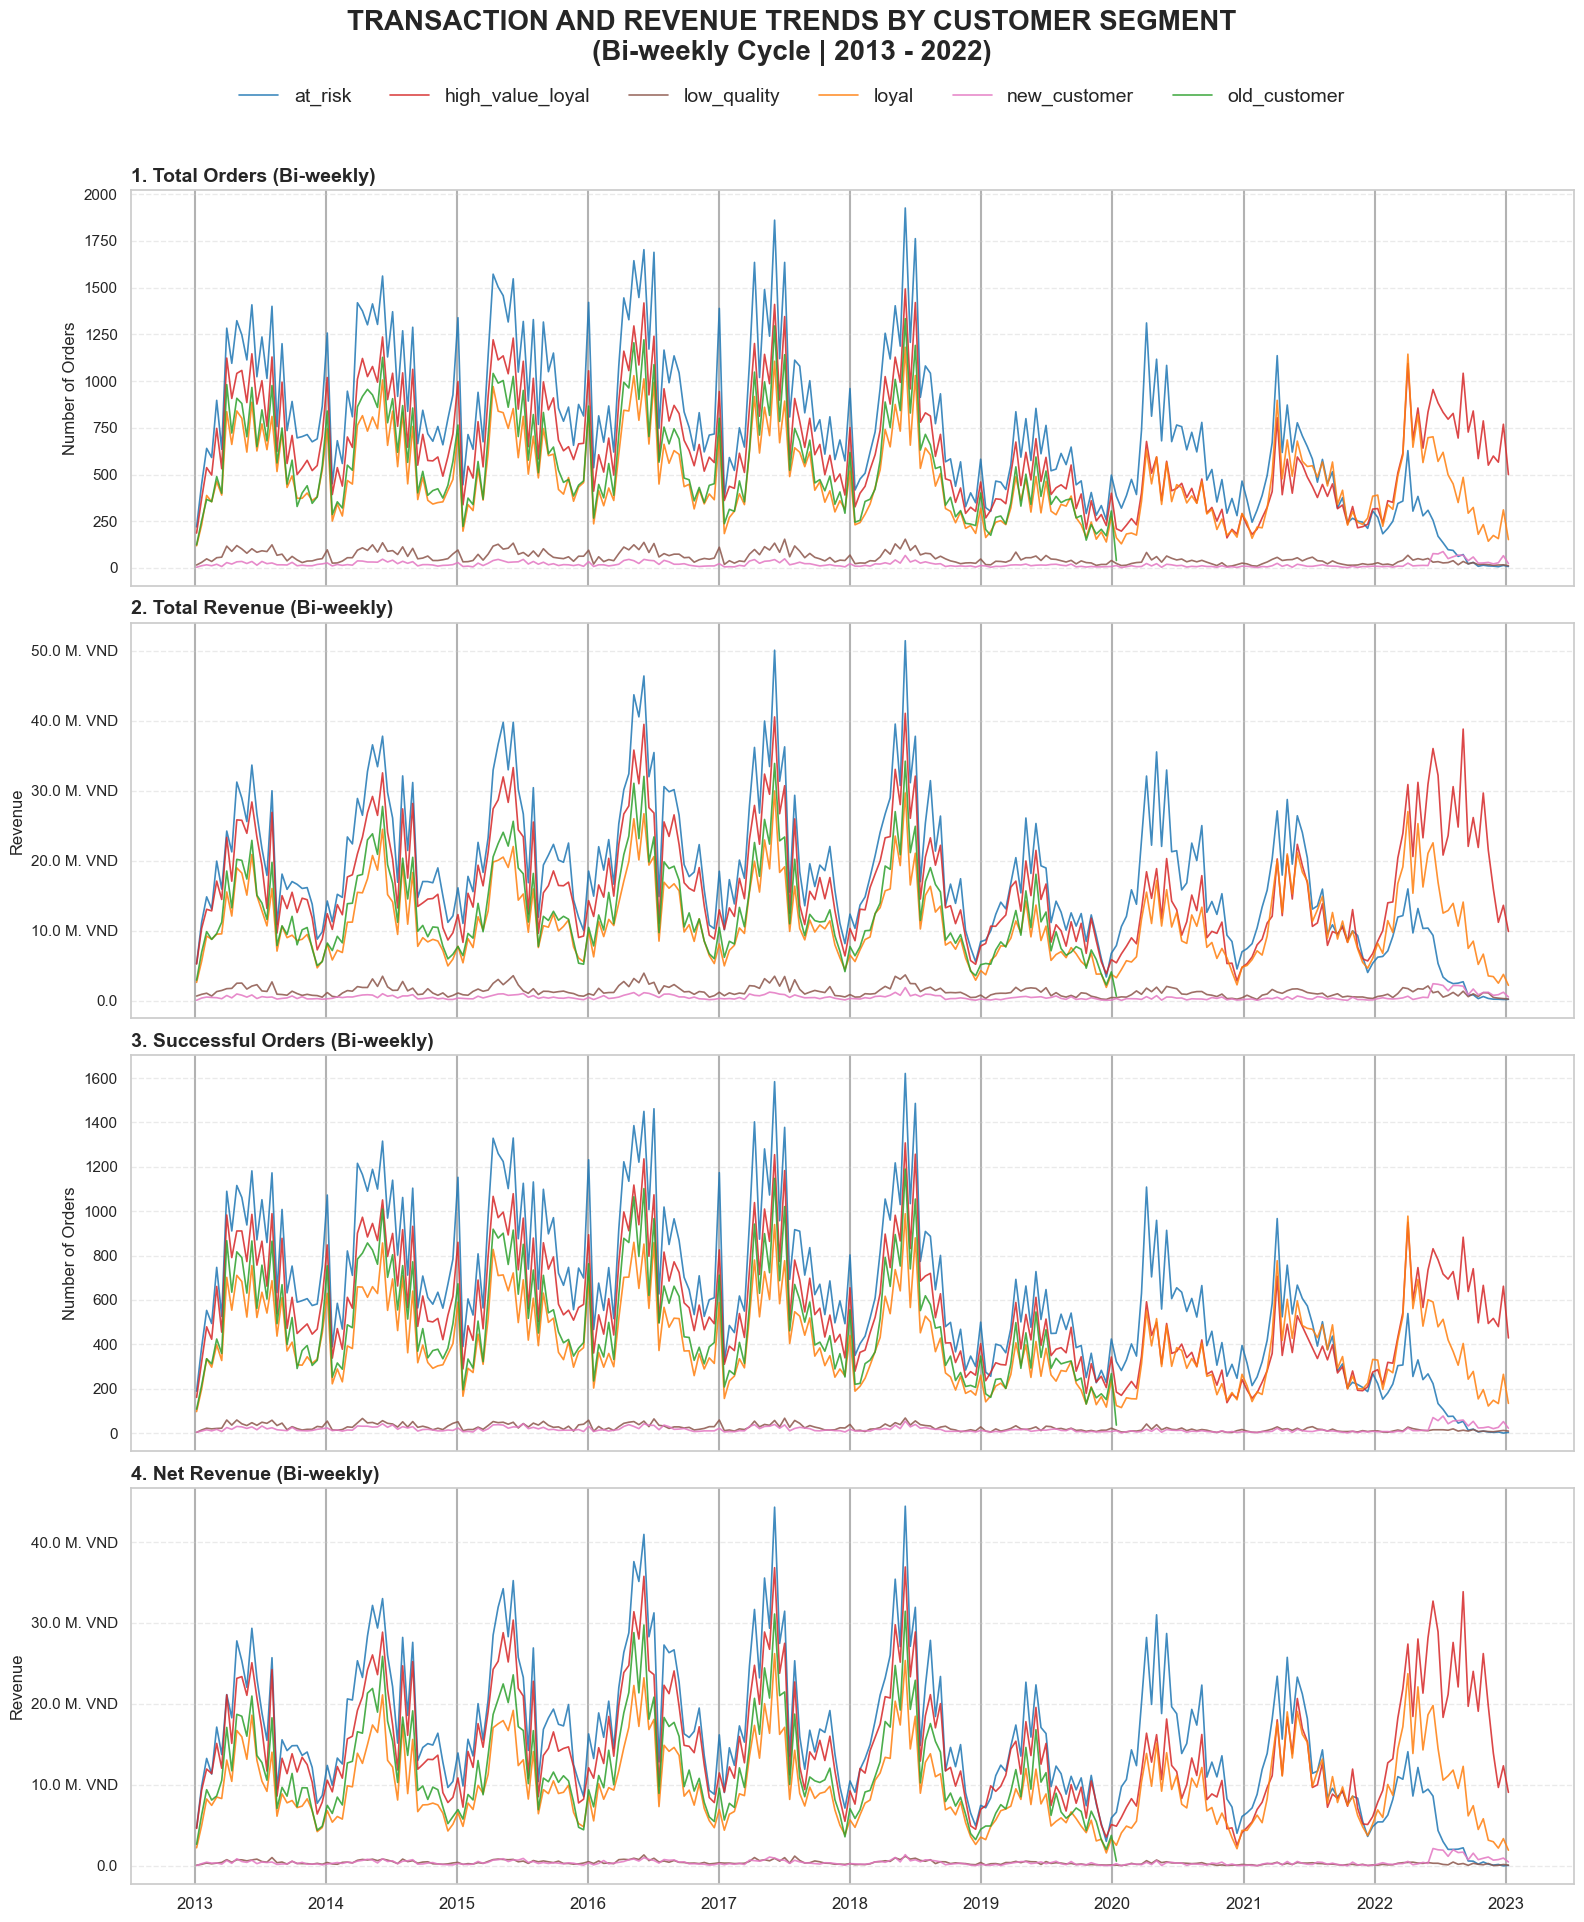

In [128]:
# Define timeframe for long-term trend analysis
start_date = '2013-01-01'
end_date = '2022-12-31'

# Customize vertical grid lines to mark yearly boundaries
year_grid_linewidth = 1.5   # Độ dày
year_grid_alpha = 0.6       # Độ đậm
year_grid_color = 'gray'    # Màu 

# Filter data within the specified timeframe
filtered_df = daily_segment_df[
    (daily_segment_df['order_date'] >= start_date) & 
    (daily_segment_df['order_date'] <= end_date)
].copy()
filtered_df['customer_segment'] = filtered_df['customer_segment'].cat.remove_unused_categories()

# Resample data to a bi-weekly ('2W') cycle and sum the metrics
biweekly_df = filtered_df.set_index('order_date') \
    .groupby('customer_segment', observed=True) \
    .resample('2W').sum().reset_index()

# Initialize a 4x1 subplot grid sharing the X-axis
fig, axes = plt.subplots(4, 1, figsize=(16, 20), sharex=True)
fig.suptitle(f'TRANSACTION AND REVENUE TRENDS BY CUSTOMER SEGMENT\n(Bi-weekly Cycle | {start_date[:4]} - {end_date[:4]})', 
             fontsize=20, fontweight='bold', y=0.96)

metrics = ['total_order', 'total_paid', 'actual_order', 'actual_paid']
titles = [
    '1. Total Orders (Bi-weekly)',
    '2. Total Revenue (Bi-weekly)',
    '3. Successful Orders (Bi-weekly)',
    '4. Net Revenue (Bi-weekly)',
]
ylabels = ['Number of Orders', 'Revenue', 'Number of Orders', 'Revenue']

def currency_formatter(x, pos):
    if x >= 1e9: return f'{x / 1e9:.1f} B. VND'
    elif x >= 1e6: return f'{x / 1e6:.1f} M. VND'
    else: return str(x)
for i, ax in enumerate(axes):
    sns.lineplot(
        data=biweekly_df,
        x='order_date',
        y=metrics[i],
        hue='customer_segment',
        palette=segment_palette,
        linewidth=1.2,
        alpha=0.85,
        ax=ax,
        legend=(i == 0)
    )
    ax.set_title(titles[i], fontsize=14, fontweight='bold', loc='left')
    ax.set_ylabel(ylabels[i], fontsize=12)
    ax.set_xlabel('')
    
    # Configure grid lines
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.grid(True, axis='x', linestyle='-', color=year_grid_color, linewidth=year_grid_linewidth, alpha=year_grid_alpha)
            
    # Apply currency formatter for revenue subplots
    if i in [1, 3]:
        ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
    
    # Extract legend handles from the first subplot and remove its localized legend
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

# Format X-axis to display only the Year
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].tick_params(axis='x', rotation=0, labelsize=12)

# Create a centralized legend at the top of the figure
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=7, fontsize=14, frameon=False)

plt.tight_layout()
# Adjust top spacing to prevent Suptitle and Legend from overlapping with plots
plt.subplots_adjust(top=0.87) 
plt.show()

#### INSIGHTS & BUSINESS IMPLICATIONS
- **Visual Context**: A 10-year bi-weekly trend analysis that filters out daily noise, allowing us to observe the business's long-term resilience and growth trajectory.
- **Key Findings**:
    - **Cyclical Growth**: Revenue spikes occur at highly predictable intervals throughout the year, followed by deep retreats to a baseline level.
    - **The Loyal Buffer**: During market downturns or "trough" months between major sales, the baseline revenue is almost entirely sustained by the `loyal` and `high_value_loyal` segments, acting as a shock absorber.
- **Actionable Recommendations**:
    - **OpEx Planning**: Operational expenditures (OpEx) should be benchmarked against the baseline revenue generated by loyal segments, rather than the annual average (which is heavily skewed by seasonal peaks).
    - **Cash Flow Management**: The deep valleys between spikes are high-risk periods for liquidity. The business must optimize inventory turnover and maintain working capital reserves for these off-peak months.

### 3.4. Seasonality Analysis (Daily Averages)
To isolate and identify annual seasonal patterns (e.g., peak shopping seasons, holiday drops), we aggregate the daily metrics across a recent 5-year period (2018-2022) and map them onto a single "dummy" year for continuous overlapping visualization.

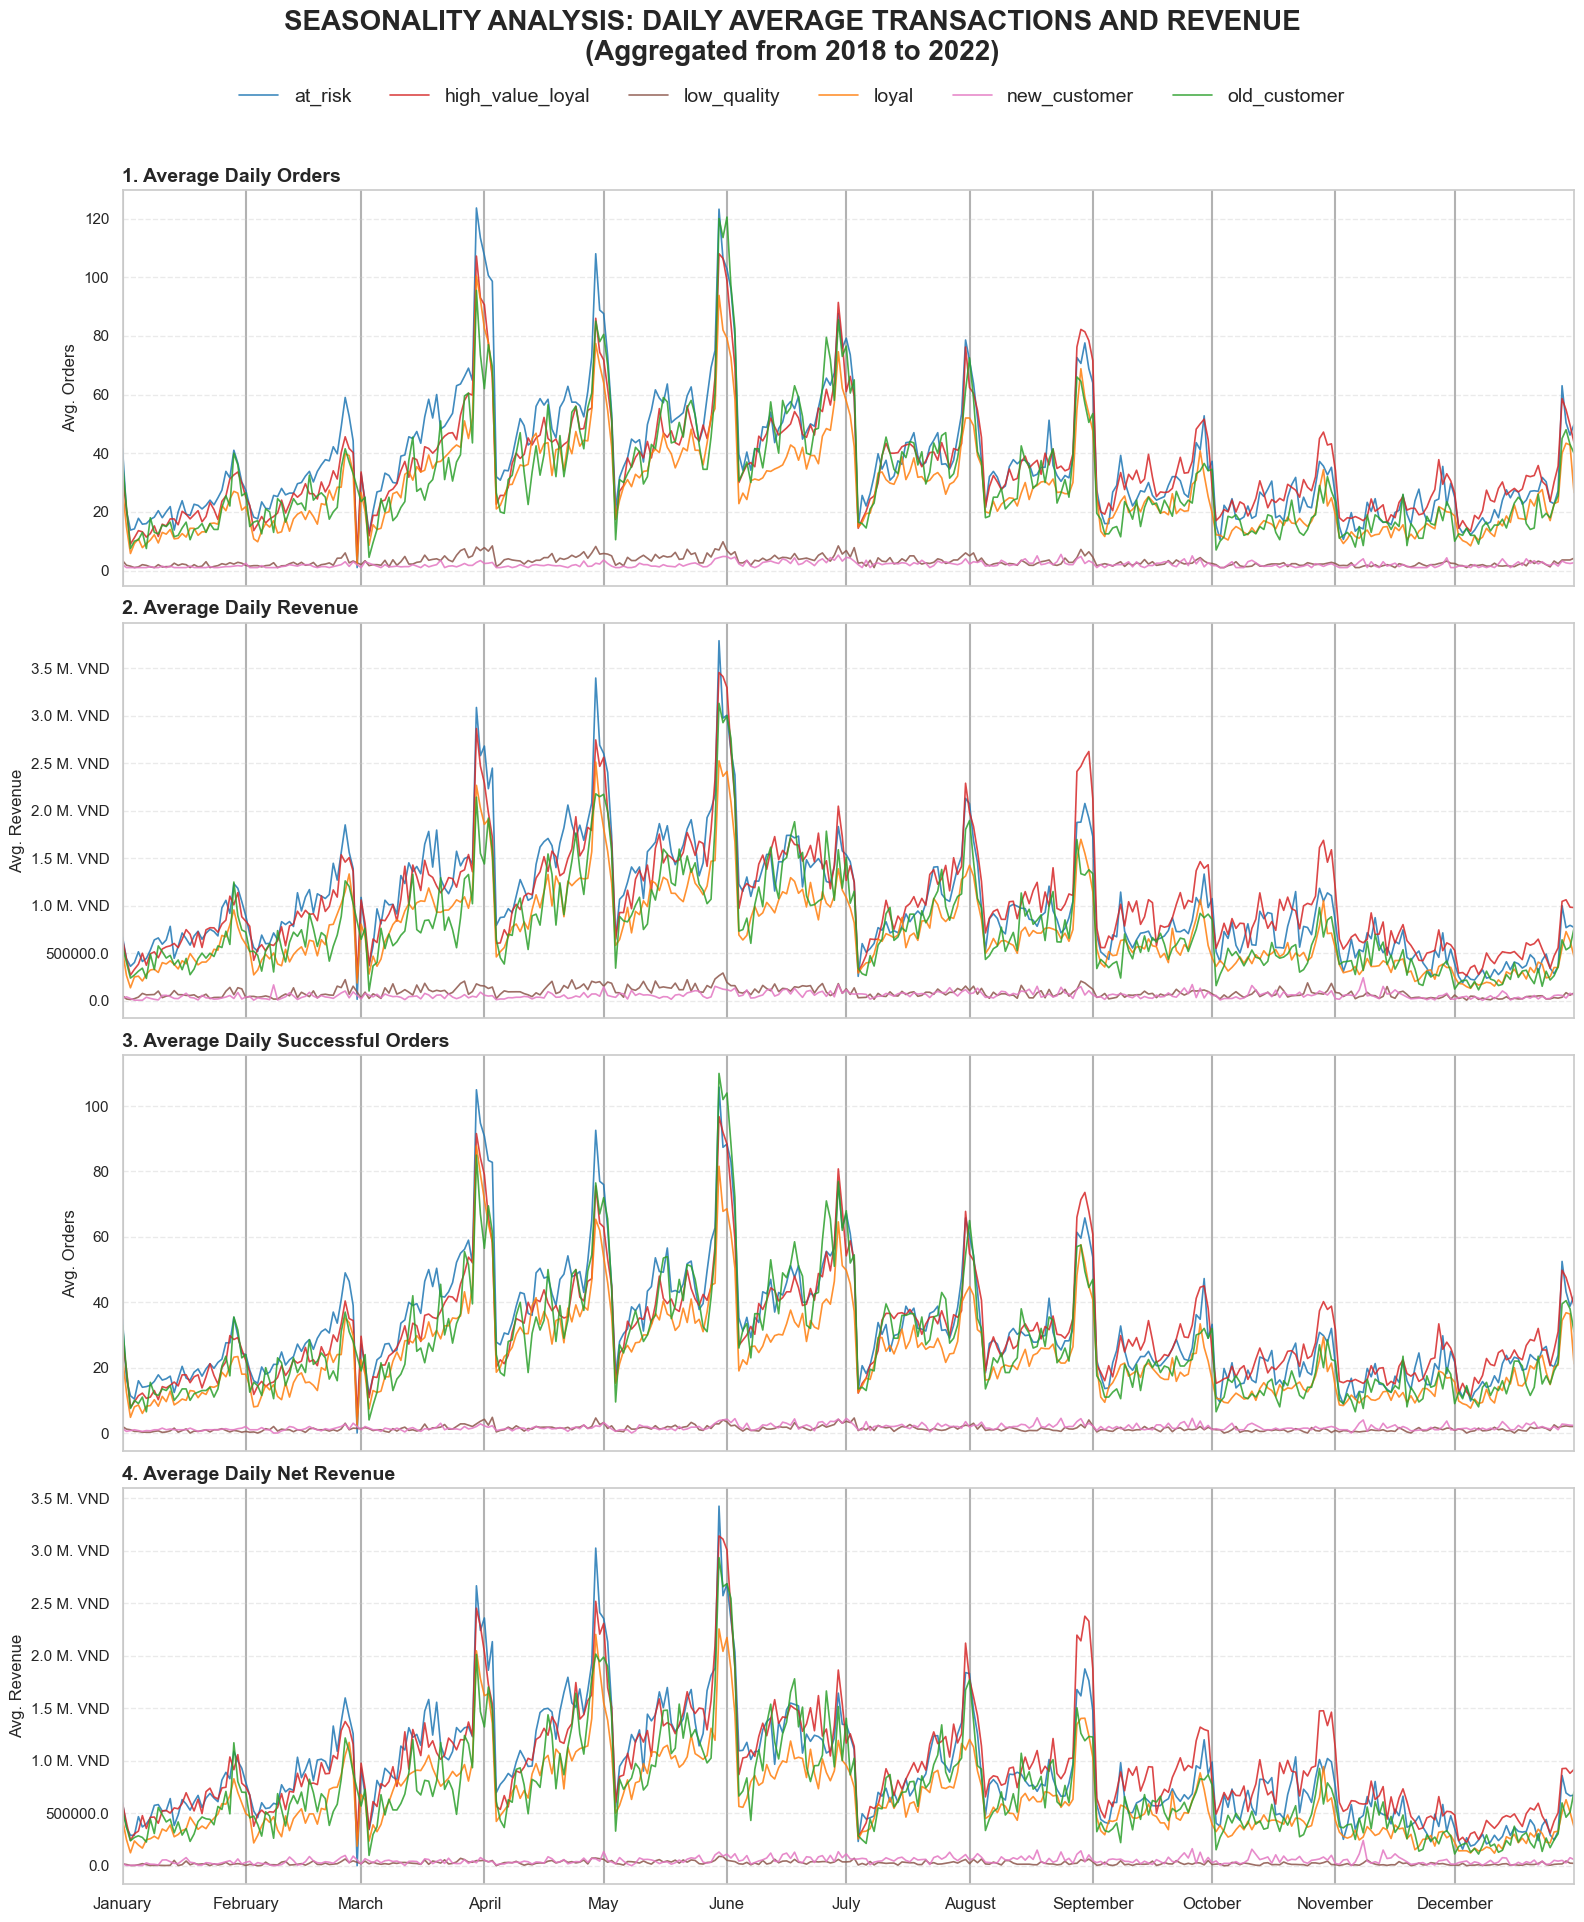

In [129]:
# Define timeframe for recent seasonality analysis
start_date = '2018-01-01'
end_date = '2022-12-31'

# Customize vertical grid lines to mark monthly boundaries
month_grid_linewidth = 1.5   # Độ dày
month_grid_alpha = 0.6       # Độ đậm
month_grid_color = 'gray'    # Màu   

# Filter data within the specified timeframe
filtered_df = daily_segment_df[
    (daily_segment_df['order_date'] >= start_date) & 
    (daily_segment_df['order_date'] <= end_date)
].copy()
filtered_df['customer_segment'] = filtered_df['customer_segment'].cat.remove_unused_categories()

# Extract Month-Day and map it to a leap dummy year (2020) to plot continuously on a single X-axis
filtered_df['month_day'] = filtered_df['order_date'].dt.strftime('%m-%d')
filtered_df['dummy_date'] = pd.to_datetime('2020-' + filtered_df['month_day'], errors='coerce')

# Aggregate the metrics by calculating the MEAN for each day of the year across all analyzed years
seasonality_df = filtered_df.groupby(['dummy_date', 'customer_segment'], observed=True)[
    ['total_order', 'total_paid', 'actual_order', 'actual_paid']
].mean().reset_index()

# Initialize a 4x1 subplot grid
fig, axes = plt.subplots(4, 1, figsize=(16, 20), sharex=True)
fig.suptitle(f'SEASONALITY ANALYSIS: DAILY AVERAGE TRANSACTIONS AND REVENUE\n(Aggregated from {start_date[:4]} to {end_date[:4]})', 
             fontsize=20, fontweight='bold', y=0.96)

metrics = ['total_order', 'total_paid', 'actual_order', 'actual_paid']
titles = [
    '1. Average Daily Orders',
    '2. Average Daily Revenue',
    '3. Average Daily Successful Orders',
    '4. Average Daily Net Revenue',
]
ylabels = ['Avg. Orders', 'Avg. Revenue', 'Avg. Orders', 'Avg. Revenue']

def currency_formatter(x, pos):
    if x >= 1e9: return f'{x / 1e9:.1f} B. VND'
    elif x >= 1e6: return f'{x / 1e6:.1f} M. VND'
    else: return str(x)
for i, ax in enumerate(axes):
    sns.lineplot(
        data=seasonality_df,
        x='dummy_date',
        y=metrics[i],
        hue='customer_segment',
        palette=segment_palette,
        linewidth=1.2, 
        alpha=0.85,
        ax=ax,
        legend=(i == 0) 
    )
    
    ax.set_title(titles[i], fontsize=14, fontweight='bold', loc='left')
    ax.set_ylabel(ylabels[i], fontsize=12)
    ax.set_xlabel('')
    
    # Configure grid lines
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.grid(True, axis='x', linestyle='-', color=month_grid_color, linewidth=month_grid_linewidth, alpha=month_grid_alpha)

    # Apply currency formatter     
    if i in [1, 3]:
        ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
        
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

# Format X-axis to display abbreviated English Month names at the start of each month
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%B'))
axes[-1].tick_params(axis='x', rotation=0, labelsize=12)
# Limit the X-axis strictly from Jan 1st to Dec 31st
axes[-1].set_xlim([pd.to_datetime('2020-01-01'), pd.to_datetime('2020-12-31')])

# Create centralized legend
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=7, fontsize=14, frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.87) 
plt.show()

#### INSIGHTS & BUSINESS IMPLICATIONS
- **Visual Context**: By overlapping 5 years of daily metrics onto a single dummy year, we can clearly identify the market's natural purchasing rhythm.
- **Key Findings**:
    - **Coordinated Peaks**: There is a synchronized surge across all customer segments during specific months (noticeably around March, June, August, and year-end).
    - **The Impulse Gap**: During peak seasons, the gap between "Total Orders" and "Successful Orders" widens significantly. This indicates impulsive buying behavior driven by FOMO, leading to higher cancellation or return rates shortly after.
- **Actionable Recommendations**:
    - **Supply Chain Readiness**: Warehouse staffing and safety stock must reach maximum capacity at least 2-3 weeks before these identifiable peaks to prevent out-of-stock revenue loss.
    - **Budget Allocation**: Stop spreading the marketing budget evenly across 12 months. Shift to a "Pulse Marketing" strategy—injecting heavy ad spend right before and during peak zones to maximize Conversion Rates.

### 3.5. Promotion Lifecycle & Distribution Analysis
Visualizing the distribution of promotional campaigns across different months and durations to identify operational patterns. We use a custom jittered bubble chart to prevent data overlap and a Gantt chart to map the standard annual promotion timeframe.

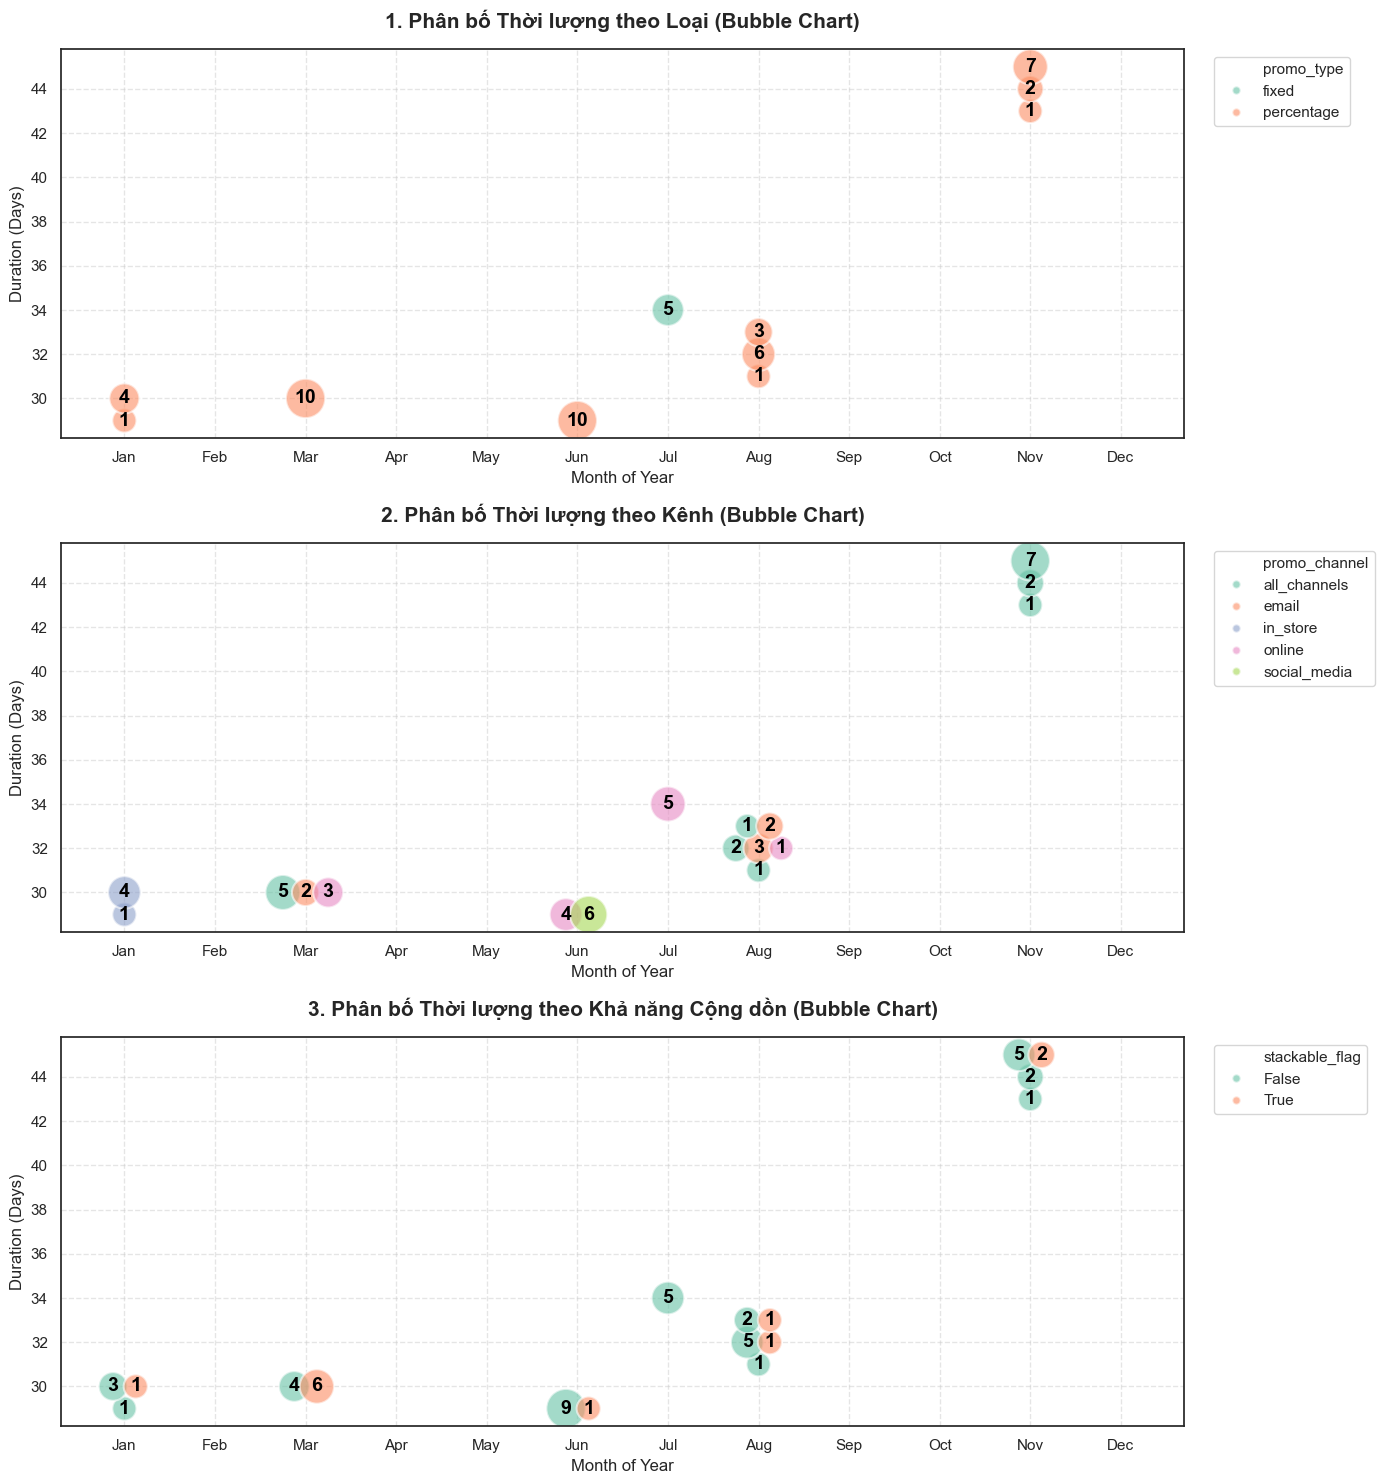

In [130]:
def draw_bubble_chart_optimized(ax, data, hue_column, title):
    # 1. Aggregate data (Remove zero-count groups)
    df_agg = data.groupby(['month', 'duration_days', hue_column]).size().reset_index(name='promo_count')
    df_agg = df_agg[df_agg['promo_count'] > 0].copy()

    # 2. JITTERING PROCESS: Slightly shift X-coordinates to prevent overlapping bubbles
    df_agg['group_size'] = df_agg.groupby(['month', 'duration_days'])['month'].transform('size')
    # Rank identical overlapping bubbles
    df_agg['rank'] = df_agg.groupby(['month', 'duration_days']).cumcount()

    # Calculate new X-coordinate (Offset from the base month)
    spacing = 0.25
    df_agg['month_jittered'] = df_agg['month'] + (df_agg['rank'] - (df_agg['group_size'] - 1) / 2) * spacing

    # 3. Draw the bubble chart using the jittered X-axis
    sns.scatterplot(
        data=df_agg,
        x='month_jittered',
        y='duration_days',
        hue=hue_column,
        size='promo_count',
        sizes=(300, 800), # bubble sizes
        alpha=0.6,
        edgecolor='white',
        linewidth=1.5,
        ax=ax,
        palette='Set2' 
    )

    # 4. Annotate the exact count inside EACH separated bubble
    for _, row in df_agg.iterrows():
        ax.text(
            row['month_jittered'],
            row['duration_days'],
            str(int(row['promo_count'])),
            color='black',
            ha='center', va='center',
            fontsize=14, 
            fontweight='bold',
        )

    # 5. Layout Presentation
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Month of Year', fontsize=12)
    ax.set_ylabel('Duration (Days)', fontsize=12)

    # Force X-axis to display exact months (1 -> 12) despite the jittering
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([calendar.month_abbr[i] for i in range(1, 13)])
    # Expand X-axis limits slightly to prevent edge bubbles from being cropped
    ax.set_xlim(0.3, 12.7) 

    # Clean up the Legend
    handles, labels = ax.get_legend_handles_labels()
    # Find the index of 'promo_count' to strip size instructions, keeping only color keys
    cut_idx = labels.index('promo_count') if 'promo_count' in labels else len(labels)
    ax.legend(handles[:cut_idx], labels[:cut_idx], bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)
    
sns.set_theme(style="white")
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

draw_bubble_chart_optimized(axes[0], df_promotions, 'promo_type', '1. Phân bố Thời lượng theo Loại (Bubble Chart)')
draw_bubble_chart_optimized(axes[1], df_promotions, 'promo_channel', '2. Phân bố Thời lượng theo Kênh (Bubble Chart)')
draw_bubble_chart_optimized(axes[2], df_promotions, 'stackable_flag', '3. Phân bố Thời lượng theo Khả năng Cộng dồn (Bubble Chart)')

plt.tight_layout()
plt.show()

#### Standard Annual Promotion Calendar Visualization

In [131]:
start_date = '2013-01-01'
end_date = '2022-12-31'
dummy_year = 2020

GRID_CONFIG = {'linewidth': 1.5, 'alpha': 0.6, 'color': 'gray'}
ALL_CAMPAIGNS = ['Rural Special', 'Spring Sale', 'Mid-year Sale', 'Urban Blowout', 'Fall Launch', 'Year-End Sale']
camp_colors = sns.color_palette('Set2', len(ALL_CAMPAIGNS))
camp_palette = dict(zip(ALL_CAMPAIGNS, camp_colors))

campaign_vn = {
    'Rural Special': 'Rural Special',
    'Spring Sale': 'Spring Sale',
    'Mid-year Sale': 'Mid-year Sale',
    'Urban Blowout': 'Urban Blowout',
    'Fall Launch': 'Fall Launch',
    'Year-End Sale': 'Year-End Sale'
}

CAMPAIGNS_EVEN = {
    'Spring Sale': [('2020-03-18', '2020-04-17')],
    'Mid-year Sale': [('2020-06-23', '2020-07-22')],
    'Fall Launch': [('2020-08-30', '2020-10-01')],
    'Year-End Sale': [('2020-01-01', '2020-01-02'), ('2020-11-18', '2020-12-31')]
}

CAMPAIGNS_ODD = {
    'Rural Special': [('2020-01-30', '2020-03-01')],
    'Spring Sale': [('2020-03-18', '2020-04-17')],
    'Mid-year Sale': [('2020-06-23', '2020-07-22')],
    'Urban Blowout': [('2020-07-30', '2020-09-02')],
    'Fall Launch': [('2020-08-30', '2020-10-01')],
    'Year-End Sale': [('2020-01-01', '2020-01-02'), ('2020-11-18', '2020-12-31')]
}


def vietnamese_months(x, pos):
    dt = mdates.num2date(x)
    return f"Tháng {dt.month}"

def currency_formatter(x, pos):
    return f"{x / 1e6:.1f} M.VND"

def apply_standard_formatting(ax):
    ax.grid(True, axis='y', linestyle='-', color='#333333', alpha=0.17)
    ax.grid(True, axis='x', linestyle='-', color=GRID_CONFIG['color'], 
            linewidth=GRID_CONFIG['linewidth'], alpha=GRID_CONFIG['alpha'])
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

def draw_campaign_spans(ax, campaign_dict):
    for camp_name, date_ranges in campaign_dict.items():
        for start, end in date_ranges:
            ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), 
                       color=camp_palette.get(camp_name, 'gray'), alpha=0.3)

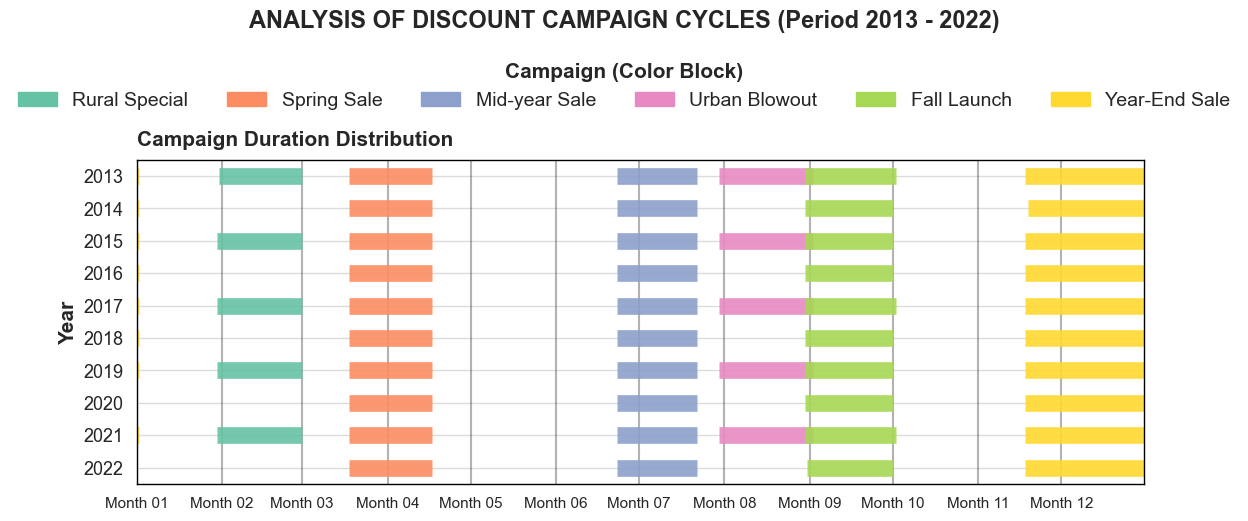

In [132]:
df_plot = df_promotions.copy()
df_plot['base_promo'] = df_plot['promo_name'].str.replace(r'\s*\d{4}$', '', regex=True).str.strip()
df_plot['base_promo'] = df_plot['base_promo'].replace({'Mid-Year Sale': 'Mid-year Sale'})

df_plot['dummy_start'] = df_plot['start_date'].apply(lambda dt: dt.replace(year=dummy_year))
df_plot['dummy_end'] = df_plot['end_date'].apply(lambda dt: dt.replace(year=dummy_year))

fig, ax = plt.subplots(figsize=(13, 6))

for idx, row in df_plot.iterrows():
    start = row['dummy_start']
    end = row['dummy_end']
    color = camp_palette[row['base_promo']]

    if end < start:
        ax.hlines(y=row['year'], xmin=start, xmax=pd.to_datetime(f'{dummy_year}-12-31'), color=color, linewidth=12, alpha=0.9)
        ax.hlines(y=row['year'], xmin=pd.to_datetime(f'{dummy_year}-01-01'), xmax=end, color=color, linewidth=12, alpha=0.9)
    else:
        ax.hlines(y=row['year'], xmin=start, xmax=end, color=color, linewidth=12, alpha=0.9)

min_year, max_year = int(df_plot['year'].min()), int(df_plot['year'].max())
ax.set_ylim(min_year - 0.5, max_year + 0.5)
ax.set_yticks(range(min_year, max_year + 1))
ax.invert_yaxis()

ax.set_xlim([pd.to_datetime(f'{dummy_year}-01-01'), pd.to_datetime(f'{dummy_year}-12-31')])
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('Month %m'))
ax.tick_params(axis='y', rotation=0, labelsize=13)
ax.tick_params(axis='x', rotation=0)

apply_standard_formatting(ax)

ax.set_ylabel('Year', fontsize=15, fontweight='bold')
ax.set_xlabel('')
ax.set_title('Campaign Duration Distribution', loc='left', fontsize=15, fontweight='bold', pad=10)

legend_patches = [mpatches.Patch(color=color, label=promo) for promo, color in camp_palette.items()]
leg = fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, 0.84), ncol=len(camp_palette), frameon=False, fontsize=14)
leg.set_title('Campaign (Color Block)', prop={'weight':'bold', 'size':15})
leg._legend_box.align = "center"

fig.suptitle('ANALYSIS OF DISCOUNT CAMPAIGN CYCLES (Period 2013 - 2022)', fontsize=17, fontweight='bold', y=0.9)
plt.subplots_adjust(top=0.65)
plt.show()

#### INSIGHTS & BUSINESS IMPLICATIONS
- **Visual Context**: A diagnostic overlay comparing transaction lines against shaded campaign windows. Splitting into Even and Odd years acts as an A/B test to isolate the impact of specific odd-year campaigns.
- **Key Findings**:
    - **Absolute Dependency**: Almost 100% of revenue and volume spikes align perfectly with the shaded promotional periods. Sales are the sole engine of sudden cash flow.
    - **The Odd-Year Filler**: In Odd years, the introduction of "*Rural Special*" and "*Urban Blowout*" perfectly fills the revenue "valleys" observed in Even years (specifically in February and August).
- **Actionable Recommendations**:
    - **Beware of Promo-Addiction**: KThe business is heavily dependent on discounting to drive sales, which severely erodes Gross Margin. Customers are trained to wait for sales.
    - **Shift to Value-Added Promos**: Transition gradually from "Deep Discounting" to "Value-Added Promotions" (e.g., Buy 3 Get 1, free samples, triple loyalty points) for the `high_value_loyal` segment. This protects margins while maintaining high order volumes.

### 3.6. Correlating Revenue with Annual Campaigns (Even vs. Odd Years)
Since some major campaigns (Rural Special, Urban Blowout) only occur in odd years, we split the temporal analysis into Even and Odd years. We overlay the exact campaign windows (shaded regions) onto the transaction lines to measure the direct impact of marketing efforts on customer purchasing behavior.

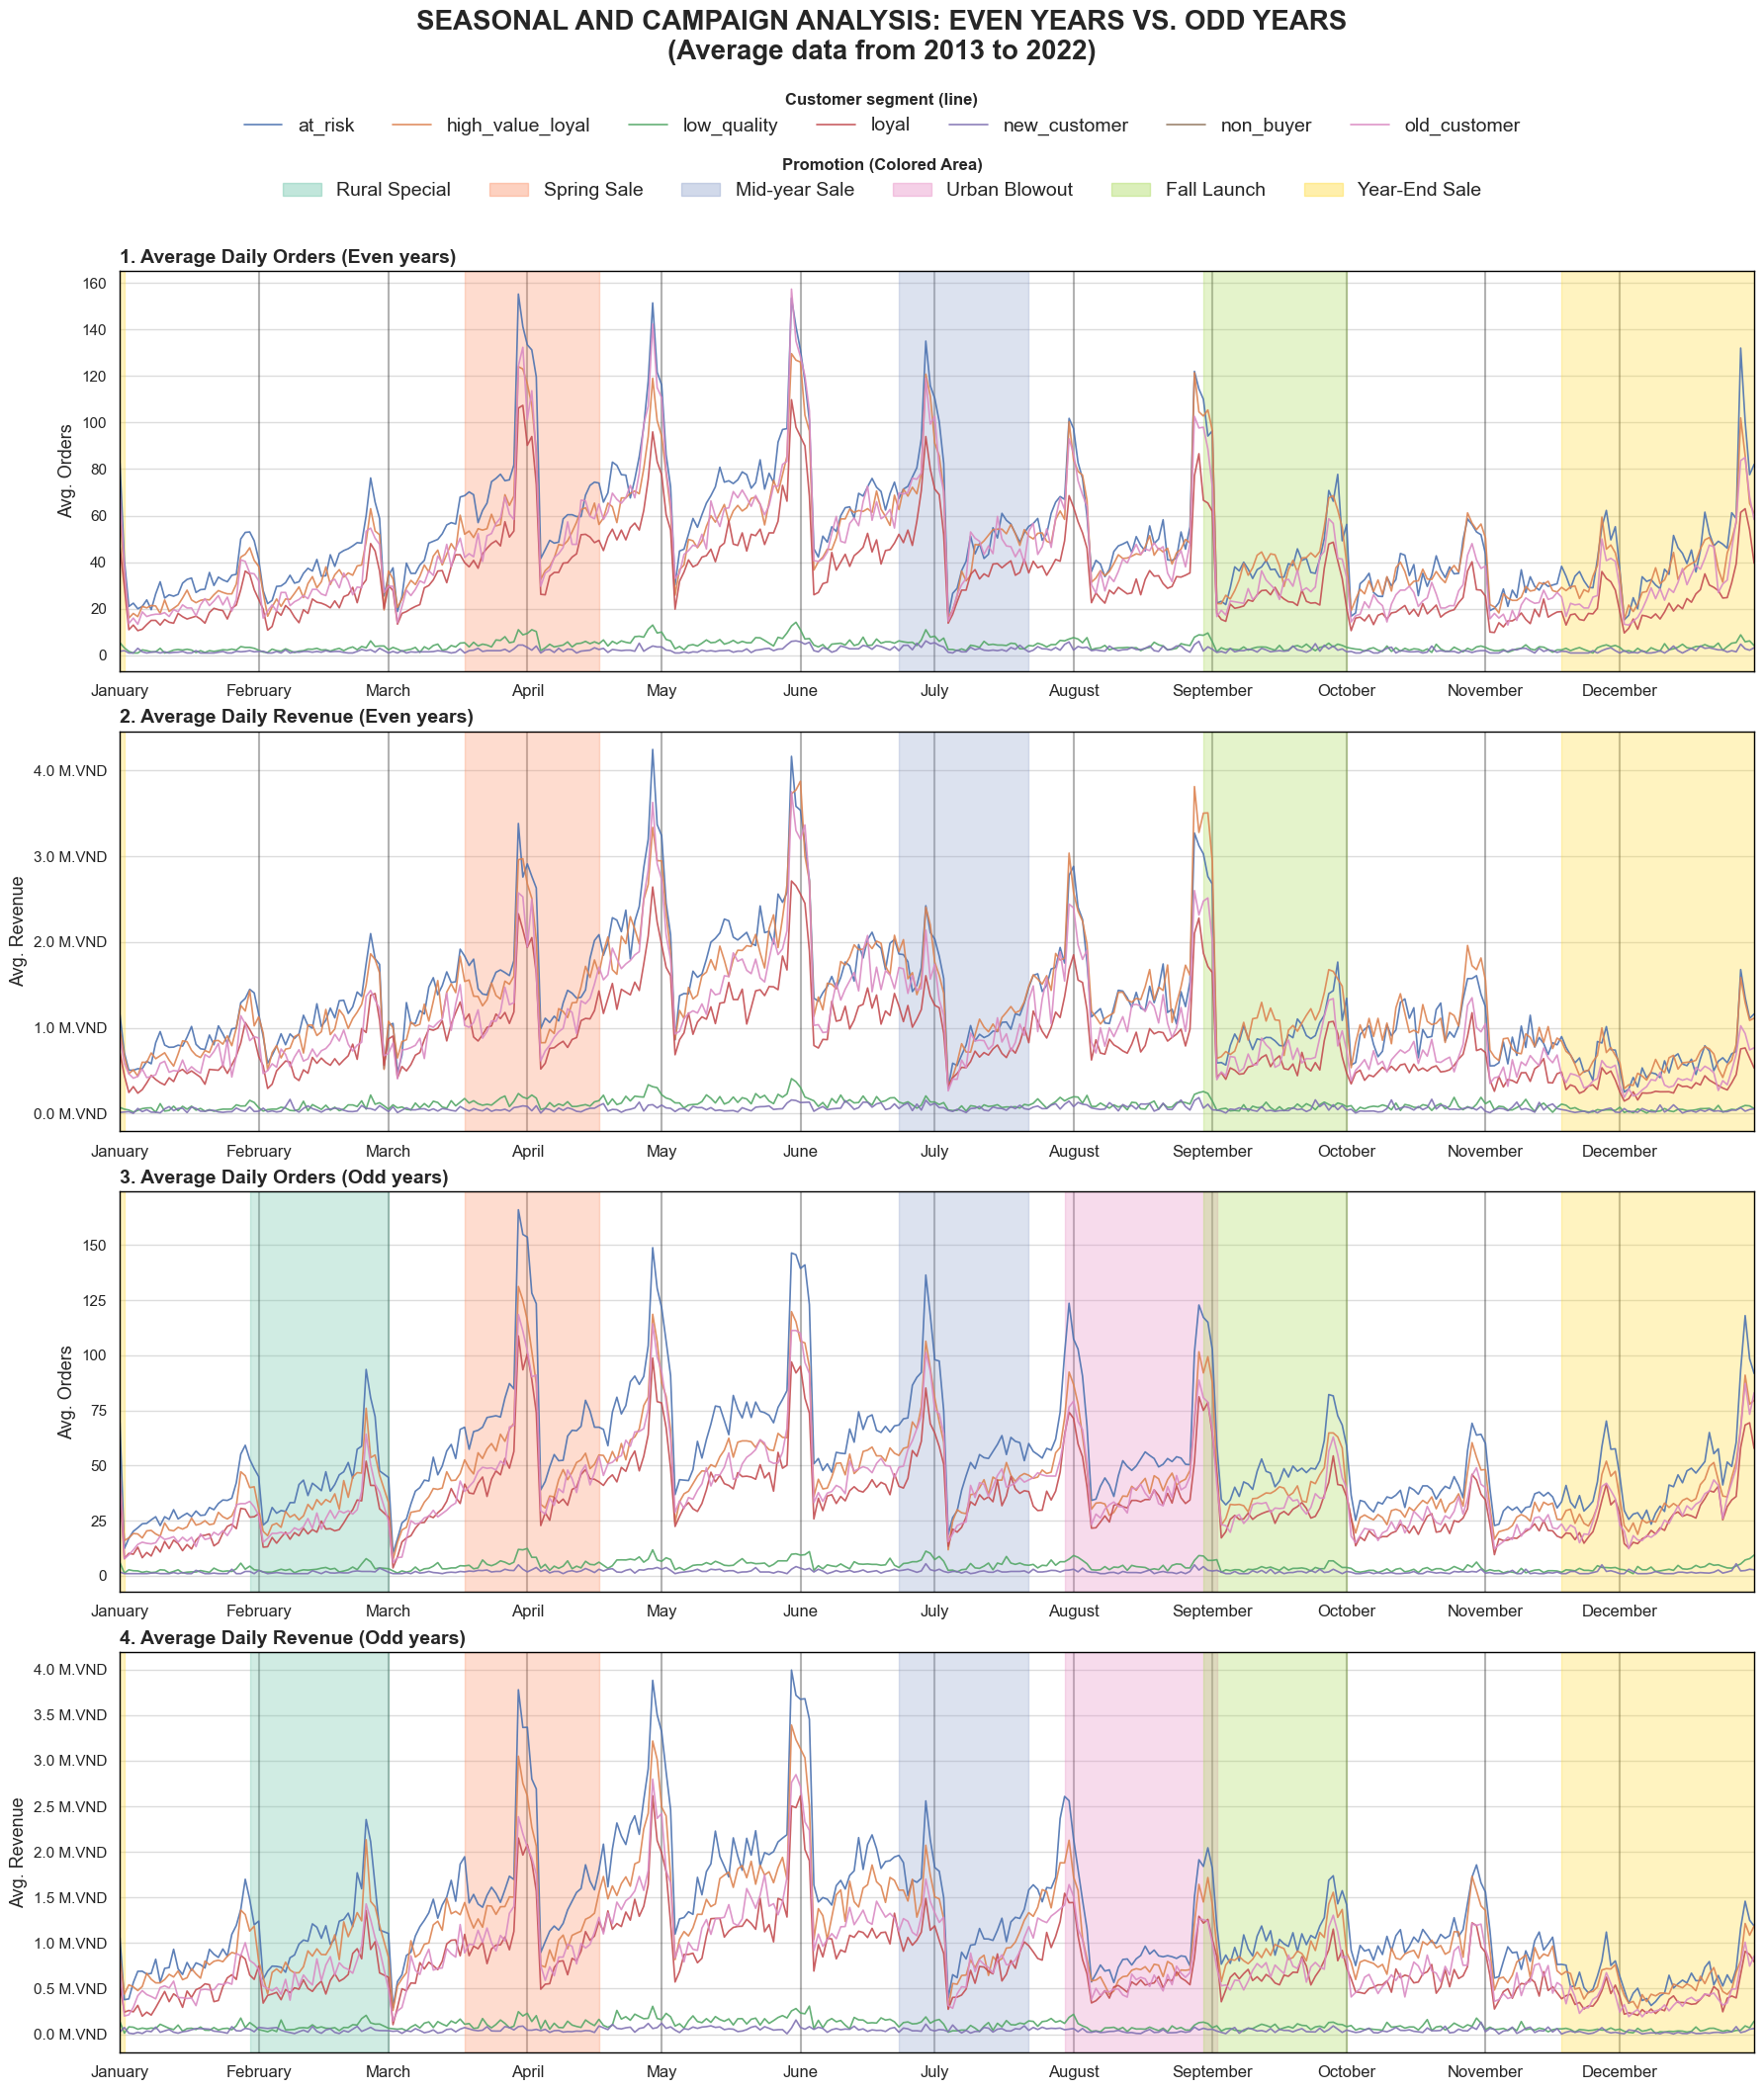

In [133]:
filtered_df = daily_segment_df[
    (daily_segment_df['order_date'] >= start_date) & 
    (daily_segment_df['order_date'] <= end_date)
].copy()

filtered_df['month_day'] = filtered_df['order_date'].dt.strftime('%m-%d')
filtered_df['dummy_date'] = pd.to_datetime(str(dummy_year) + '-' + filtered_df['month_day'], errors='coerce')
filtered_df['is_even_year'] = filtered_df['order_date'].dt.year % 2 == 0

even_df = filtered_df[filtered_df['is_even_year']].groupby(['dummy_date', 'customer_segment'], observed=True)[['total_order', 'total_paid']].mean().reset_index()
odd_df = filtered_df[~filtered_df['is_even_year']].groupby(['dummy_date', 'customer_segment'], observed=True)[['total_order', 'total_paid']].mean().reset_index()

fig, axes = plt.subplots(4, 1, figsize=(18, 22), sharex=True)
fig.suptitle(f'SEASONAL AND CAMPAIGN ANALYSIS: EVEN YEARS VS. ODD YEARS\n(Average data from {start_date[:4]} to {end_date[:4]})', 
             fontsize=20, fontweight='bold', y=0.96)

plot_configs = [
    (even_df, 'total_order', '1. Average Daily Orders (Even years)', CAMPAIGNS_EVEN),
    (even_df, 'total_paid', '2. Average Daily Revenue (Even years)', CAMPAIGNS_EVEN),
    (odd_df, 'total_order', '3. Average Daily Orders (Odd years)', CAMPAIGNS_ODD),
    (odd_df, 'total_paid', '4. Average Daily Revenue (Odd years)', CAMPAIGNS_ODD)
]
ylabels = ['Avg. Orders', 'Avg. Revenue', 'Avg. Orders', 'Avg. Revenue']

for i, ax in enumerate(axes):
    data, y_col, title, camp_dict = plot_configs[i]
    
    sns.lineplot(data=data, x='dummy_date', y=y_col, hue='customer_segment', 
                 linewidth=1.2, alpha=0.9, ax=ax, legend=(i==0))
    
    draw_campaign_spans(ax, camp_dict)
    
    ax.set_title(title, fontsize=14, fontweight='bold', loc='left')
    ax.set_ylabel(ylabels[i], fontsize=13)
    ax.set_xlabel('')
    apply_standard_formatting(ax)
    
    if i in [1, 3]:
        ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
        
    if i == 0:
        handles_seg, labels_seg = ax.get_legend_handles_labels()
        ax.get_legend().remove()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
    ax.tick_params(axis='x', rotation=0, labelsize=12, labelbottom=True)
    ax.set_xlim([pd.to_datetime(f'{dummy_year}-01-01'), pd.to_datetime(f'{dummy_year}-12-31')])

leg1 = fig.legend(handles=handles_seg, labels=labels_seg, loc='upper center', bbox_to_anchor=(0.5, 0.93), 
                  ncol=7, fontsize=14, frameon=False, title="Customer segment (line)")
leg1.get_title().set_fontweight('bold')

camp_handles = [mpatches.Patch(color=camp_palette[c], alpha=0.4, label=c) for c in ALL_CAMPAIGNS]
leg2 = fig.legend(handles=camp_handles, loc='upper center', bbox_to_anchor=(0.5, 0.90), 
                  ncol=6, fontsize=14, frameon=False, title="Promotion (Colored Area)")
leg2.get_title().set_fontweight('bold')

plt.tight_layout()
plt.subplots_adjust(top=0.84, hspace=0.15)
plt.show()

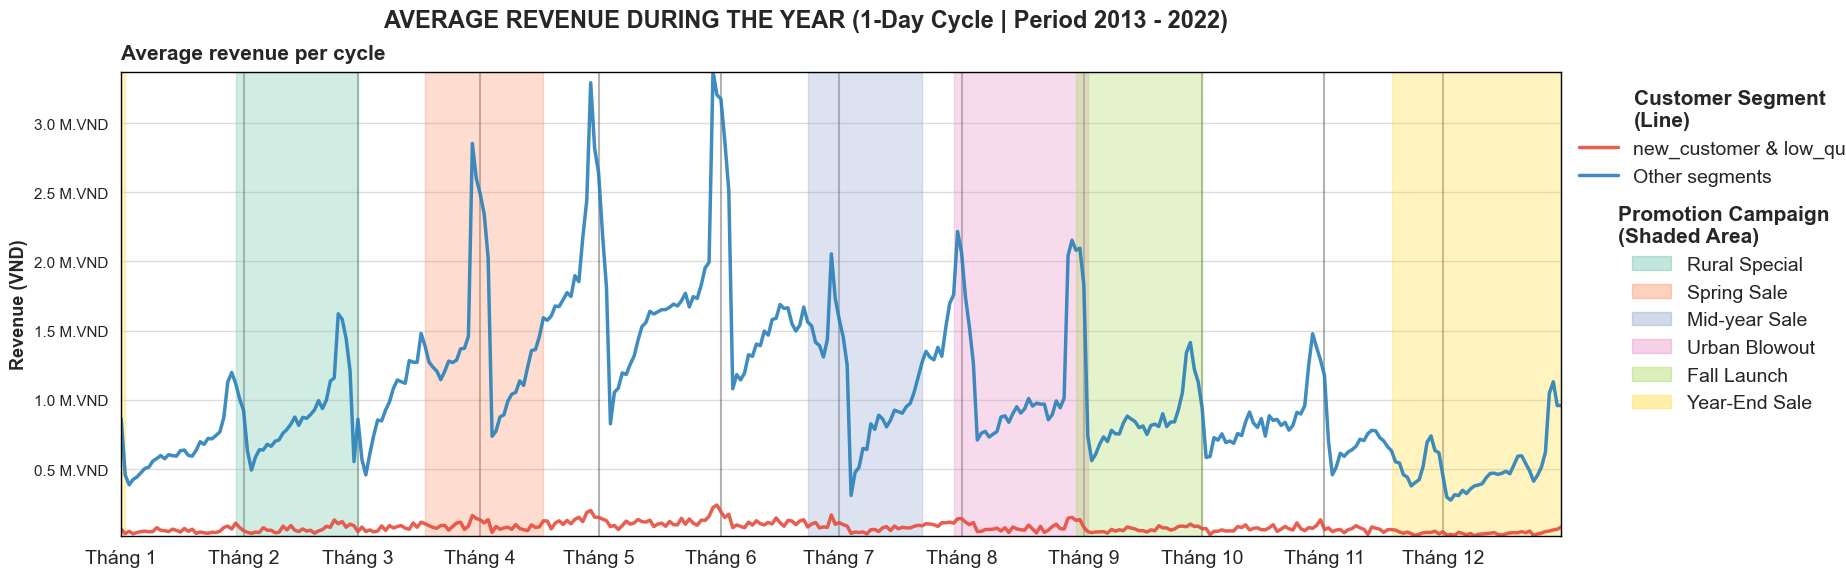

In [134]:
df_all_years = daily_segment_df[
    (daily_segment_df['order_date'] >= start_date) & 
    (daily_segment_df['order_date'] <= end_date) & 
    (daily_segment_df['customer_segment'] != 'non_buyer')
].copy()

target_segments = ['new_customer', 'low_quality']
df_all_years['grouped_segment'] = np.where(df_all_years['customer_segment'].isin(target_segments),
                                           'new_customer & low_quality', 'Other segments')

df_all_years['month_day'] = df_all_years['order_date'].dt.strftime('%m-%d')
df_all_years['dummy_date'] = pd.to_datetime(str(dummy_year) + '-' + df_all_years['month_day'], errors='coerce')

avg_revenue_df = df_all_years.groupby(['dummy_date', 'grouped_segment'])['total_paid'].mean().reset_index()

fig, ax = plt.subplots(figsize=(22, 6))
fig.suptitle(f'AVERAGE REVENUE DURING THE YEAR (1-Day Cycle | Period {start_date[:4]} - {end_date[:4]})', 
             fontsize=17, fontweight='bold', y=0.96, x=0.37)

sns.lineplot(data=avg_revenue_df, x='dummy_date', y='total_paid', hue='grouped_segment',
             hue_order=['new_customer & low_quality', 'Other segments'],
             palette=['#e74c3c', '#2980b9'], linewidth=2.5, alpha=0.9, ax=ax)

draw_campaign_spans(ax, CAMPAIGNS_ODD)

ax.set_title('Average revenue per cycle', fontsize=15, fontweight='bold', loc='left', pad=9)
ax.set_ylabel('Revenue (VND)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.margins(y=0)

apply_standard_formatting(ax)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(vietnamese_months))

ax.tick_params(axis='x', rotation=0, labelsize=14)
ax.set_xlim([pd.to_datetime(f'{dummy_year}-01-01'), pd.to_datetime(f'{dummy_year}-12-31')])
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

handles_seg, labels_seg = ax.get_legend_handles_labels()
ax.get_legend().remove()

leg1 = ax.legend(handles=handles_seg, labels=labels_seg,
                 loc='upper left', bbox_to_anchor=(1, 1),
                 ncol=1, fontsize=14, frameon=False,
                 title="Customer Segment\n(Line)",
                 title_fontsize=15)
leg1.get_title().set_fontweight('bold')
ax.add_artist(leg1)

camp_handles = [mpatches.Patch(color=camp_palette[c], alpha=0.4, label=campaign_vn.get(c, c)) for c in CAMPAIGNS_ODD.keys()]

leg2 = ax.legend(handles=camp_handles,
                 loc='upper left', bbox_to_anchor=(1.027, 0.75),
                 ncol=1, fontsize=14, frameon=False,
                 title="Promotion Campaign\n(Shaded Area)",
                 title_fontsize=15)
leg2.get_title().set_fontweight('bold')
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()